# 05 — Subang & West Java Maize Productivity (DS05)
**TaniAdapt Project — Regional Maize Outcome Target**
**Fase:** Phase 3 (Discovery & Acquisition) + Phase 4 (Dataset Quality Audit)

- **Sumber Resmi:** Dinas Tanaman Pangan dan Hortikultura Jawa Barat / Galura Data Jabar
- **Cakupan Wilayah:** 27 Kabupaten/Kota di Jawa Barat (2015–2022) termasuk fokus utama Kabupaten Subang
- **Temuan Kritis Audit:**
  1. Kabupaten Subang **belum memiliki titik cuaca AgERA5 langsung** di repo saat ini (jarak ke Purwakarta ~35 km, Karawang ~58 km).
  2. Kenaikan produktivitas Subang dari 57,23 ke 89,49 ku/ha pada 2020–2022 (+56,4%) mencerminkan **Patahan Struktural (Structural Break)** akibat metodologi statistik BPS (Kerangka Sampel Area) atau intensifikasi benih hibrida, bukan murni variabilitas cuaca.


In [1]:
from pathlib import Path
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name.lower() == "notebook" else CWD
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "DS05_subang_maize_productivity"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project Root:", PROJECT_ROOT)
print("Raw Data Dir:", RAW_DIR)


Project Root: C:\CODING\research_taniAdapt
Raw Data Dir: C:\CODING\research_taniAdapt\data\raw\DS05_subang_maize_productivity


## Phase 3 & 4 — Audit Integritas Data Jagung & Filter Kabupaten Subang
Membaca dataset resmi jagung Jawa Barat (216 baris = 27 wilayah x 8 tahun) dan mengisolasi runtun waktu Kabupaten Subang.


In [2]:
df_maize = pd.read_csv(RAW_DIR / "produktivitas_jagung_jabar.csv")
print("Dimensi Data Jagung Jabar:", df_maize.shape)
print("Missing Values Produktivitas:", df_maize['produktivitas_jagung'].isnull().sum())

# Filter Kabupaten Subang
subang_data = df_maize[df_maize['nama_kabupaten_kota'].str.contains('SUBANG', case=False, na=False)].sort_values('tahun')
print(f"Data Spesifik Kabupaten Subang Ditemukan: {len(subang_data)} tahun (2015–2022)")
display(subang_data[['tahun', 'nama_kabupaten_kota', 'produktivitas_jagung', 'satuan']])

# Analisis Lonjakan (Structural Break Check)
x_sub = subang_data['tahun'].values
y_sub = subang_data['produktivitas_jagung'].values
p_sub = np.polyfit(x_sub, y_sub, 1)
y_pred_sub = np.polyval(p_sub, x_sub)
resid_sub = y_sub - y_pred_sub
cv_raw = np.std(y_sub) / np.mean(y_sub) * 100
cv_resid = np.std(resid_sub) / np.mean(y_sub) * 100

print("\n" + "="*50)
print(f"ANALISIS TREN & DETRENDING JAGUNG SUBANG:")
print(f"  Slope Kenaikan Linier : +{p_sub[0]:.2f} ku/ha per tahun")
print(f"  CV Raw (Sebelum Detrend): {cv_raw:.2f}%")
print(f"  CV Residual (Sinyal Sisa): {cv_resid:.2f}% (Porsi variasi yang bisa dijelaskan cuaca)")
print("="*50)


Dimensi Data Jagung Jabar: (216, 8)
Missing Values Produktivitas: 0
Data Spesifik Kabupaten Subang Ditemukan: 8 tahun (2015–2022)


,tahun,nama_kabupaten_kota,produktivitas_jagung,satuan
12,2015,KABUPATEN SUBANG,45.75,KUINTAL/HEKTAR
39,2016,KABUPATEN SUBANG,51.53,KUINTAL/HEKTAR
66,2017,KABUPATEN SUBANG,50.64,KUINTAL/HEKTAR
93,2018,KABUPATEN SUBANG,51.38,KUINTAL/HEKTAR
120,2019,KABUPATEN SUBANG,56.41,KUINTAL/HEKTAR
147,2020,KABUPATEN SUBANG,57.23,KUINTAL/HEKTAR
174,2021,KABUPATEN SUBANG,68.20,KUINTAL/HEKTAR
201,2022,KABUPATEN SUBANG,89.49,KUINTAL/HEKTAR



ANALISIS TREN & DETRENDING JAGUNG SUBANG:
  Slope Kenaikan Linier : +4.93 ku/ha per tahun
  CV Raw (Sebelum Detrend): 22.35%
  CV Residual (Sinyal Sisa): 11.42% (Porsi variasi yang bisa dijelaskan cuaca)


## Visualisasi Diagnostik Multi-Panel (Subang Structural Jump & Ranking Top-5 Kabupaten)
Panel 1 menampilkan runtun waktu Subang vs Jabar dengan garis tren patahan; Panel 2 menampilkan ranking Top-5 sentra jagung tahun 2022.


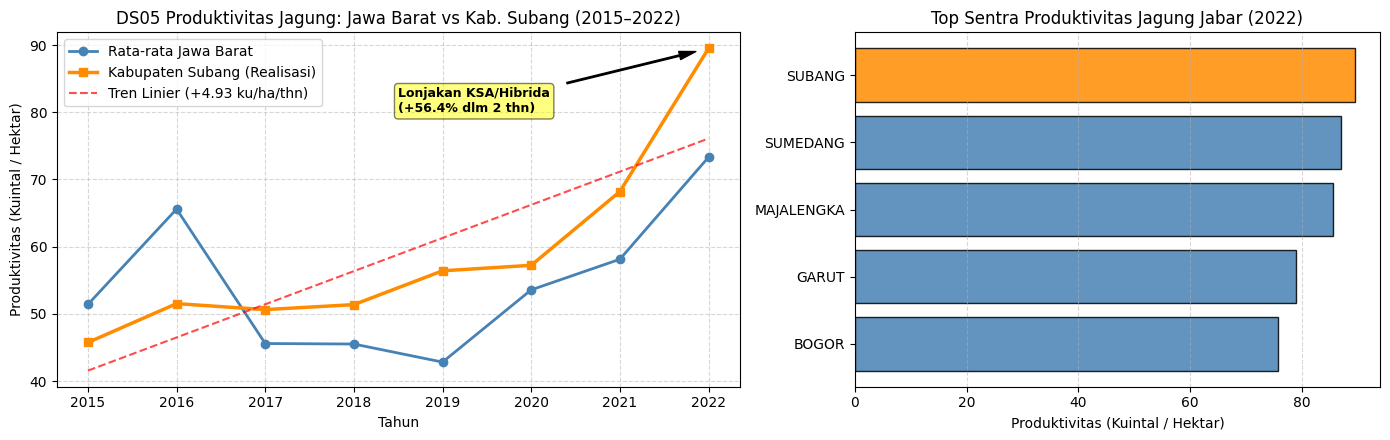

Gambar PNG berhasil disimpan ke: C:\CODING\research_taniAdapt\reports\figures\ds05_maize_coverage.png


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={'width_ratios': [1.3, 1]})

# Panel 1: Runtun Waktu Subang vs Rata-rata Jabar + Garis Tren
mean_jabar = df_maize.groupby('tahun')['produktivitas_jagung'].mean()
ax1.plot(mean_jabar.index, mean_jabar.values, marker='o', label='Rata-rata Jawa Barat', color='steelblue', linewidth=2)
ax1.plot(subang_data['tahun'], subang_data['produktivitas_jagung'], marker='s', label='Kabupaten Subang (Realisasi)', color='darkorange', linewidth=2.5)
ax1.plot(x_sub, y_pred_sub, linestyle='--', color='red', alpha=0.7, label=f'Tren Linier (+{p_sub[0]:.2f} ku/ha/thn)')

# Anotasi Structural Break
ax1.annotate('Lonjakan KSA/Hibrida\n(+56.4% dlm 2 thn)', xy=(2022, 89.49), xytext=(2018.5, 80),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6),
             fontsize=9, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5))

ax1.set_title("DS05 Produktivitas Jagung: Jawa Barat vs Kab. Subang (2015–2022)")
ax1.set_xlabel("Tahun")
ax1.set_ylabel("Produktivitas (Kuintal / Hektar)")
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.5)

# Panel 2: Ranking Top-5 Kabupaten (Tahun 2022) vs Subang
df_2022 = df_maize[df_maize['tahun'] == 2022].sort_values('produktivitas_jagung', ascending=False)
top5 = df_2022.head(5).copy()
subang_row = df_2022[df_2022['nama_kabupaten_kota'].str.contains('SUBANG', case=False)]
if not subang_row.empty and subang_row.index[0] not in top5.index:
    top5 = pd.concat([top5, subang_row])

top5_sorted = top5.sort_values('produktivitas_jagung', ascending=True)
bar_colors = ['darkorange' if 'SUBANG' in name.upper() else 'steelblue' for name in top5_sorted['nama_kabupaten_kota']]
ax2.barh(top5_sorted['nama_kabupaten_kota'].str.replace('KABUPATEN ', ''), top5_sorted['produktivitas_jagung'], color=bar_colors, edgecolor='black', alpha=0.85)
ax2.set_title("Top Sentra Produktivitas Jagung Jabar (2022)")
ax2.set_xlabel("Produktivitas (Kuintal / Hektar)")
ax2.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
png_out = FIGURES_DIR / "ds05_maize_coverage.png"
plt.savefig(png_out, dpi=150)
plt.show()
print(f"Gambar PNG berhasil disimpan ke: {png_out}")


## Executive Audit Scorecard


In [4]:
scorecard = pd.DataFrame([
    {"Dimensi Audit": "Dataset Identifier", "Hasil & Evaluasi": "DS05 — Subang & West Java Maize Productivity"},
    {"Dimensi Audit": "Penerbit & Sumber", "Hasil & Evaluasi": "Distanhor Jabar / Galura Open Data Jabar"},
    {"Dimensi Audit": "Cakupan Wilayah", "Hasil & Evaluasi": "27 Kabupaten/Kota (Fokus Utama Kabupaten Subang)"},
    {"Dimensi Audit": "Rentang Periode", "Hasil & Evaluasi": "2015 s.d. 2022 (8 Tahun Observasi Lengkap)"},
    {"Dimensi Audit": "Kelengkapan Nilai", "Hasil & Evaluasi": "PASSED (216 baris penuh, 0 missing value)"},
    {"Dimensi Audit": "Matching Cuaca Riil", "Hasil & Evaluasi": "Subang Unmatched pada 7 titik AgERA5 saat ini (Perlu ekstraksi koordinat centroid)"},
    {"Dimensi Audit": "Peran di TaniAdapt", "Hasil & Evaluasi": "Regional Maize Outcome Target"},
    {"Dimensi Audit": "Status Disposisi", "Hasil & Evaluasi": "PASS (Target hasil panen jagung regional valid)"},
    {"Dimensi Audit": "Batasan Kritis", "Hasil & Evaluasi": "Lonjakan tajam 2021-2022 mencerminkan perubahan metodologi BPS KSA/benih hibrida; sinyal cuaca berada pada residu detrending ~11%."}
])

display(scorecard)


,Dimensi Audit,Hasil & Evaluasi
0,Dataset Identifier,DS05 — Subang & West Java Maize Productivity
1,Penerbit & Sumber,Distanhor Jabar / Galura Open Data Jabar
2,Cakupan Wilayah,27 Kabupaten/Kota (Fokus Utama Kabupaten Subang)
3,Rentang Periode,2015 s.d. 2022 (8 Tahun Observasi Lengkap)
4,Kelengkapan Nilai,"PASSED (216 baris penuh, 0 missing value)"
5,Matching Cuaca Riil,Subang Unmatched pada 7 titik AgERA5 saat ini ...
6,Peran di TaniAdapt,Regional Maize Outcome Target
7,Status Disposisi,PASS (Target hasil panen jagung regional valid)
8,Batasan Kritis,Lonjakan tajam 2021-2022 mencerminkan perubaha...
